In [1]:
%load_ext autoreload
%autoreload 2
%reset -f
%matplotlib inline

In [2]:
from locallib.picarrodb import *
from locallib.query import *

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal
from BOCPD import bocpd_multivariate

import sys
sys.path.insert(0, "..")
from plot_feature_distributions_compare import plot_feature_distributions_compare


EU1_Conn created successfully
EU2_Conn created successfully
DataHub_Conn created successfully
US_Conn created successfully
EU1_PROD_Conn created successfully
EU2_PROD_Conn created successfully


In [3]:
a = get_users(customer_name = 'ENBW', user_table = '#TempUser')
b = get_surveys(user_table = '#TempUser', survey_table = '#TempSurvey', start_date = '2025-01-01')
b.set_child(Query(
    query = (
        "SELECT "
        "COUNT(P.Id) AS PeakCount, "
        "P.SurveyId, "
        "SQA.AverageFlowRate "
        "INTO #TempPeak "
        "FROM Peak P "
        "LEFT JOIN SurveyQACheck SQA ON P.SurveyId = SQA.SurveyId "
        "WHERE P.SurveyId IN (SELECT SurveyId FROM #TempSurvey) "
   
        "GROUP BY P.SurveyId, SQA.AverageFlowRate"
    )
))
a.set_child(b)
data = a.execute(EU1_Conn, table_return = ['#TempPeak', '#TempSurvey'])

peak_survey = pd.merge(data['#TempSurvey'][['SurveyId', 'SurveyorUnit','RawDurationMinutes','StartDateTime','EndDateTime']], data['#TempPeak'][['PeakCount', 'SurveyId', 'AverageFlowRate']], on = 'SurveyId', how = 'left')
peak_survey['AverageFlowRate'] = peak_survey['AverageFlowRate'].astype(float)
peak_survey = peak_survey.dropna(subset=['AverageFlowRate'])

peak_survey['PeakMinutes'] = peak_survey['PeakCount'] / peak_survey['RawDurationMinutes']

In [4]:
surveyors = peak_survey['SurveyorUnit'].unique()[0]
subset = peak_survey[peak_survey['SurveyorUnit'] == surveyors].sort_values('StartDateTime')

# Define Q1 where StartDateTime is from 28-11-25 to 22-07-26
q1_start = pd.to_datetime("2025-11-28")
q1_end = pd.to_datetime("2026-07-22")

leak = subset[(subset['StartDateTime'] >= q1_start) & (subset['StartDateTime'] <= q1_end)].sort_values('StartDateTime')
normal = subset[(subset['StartDateTime'] < q1_start) | (subset['StartDateTime'] > q1_end)].sort_values('StartDateTime')

Q = subset['AverageFlowRate']
Y = subset['PeakMinutes']
t = subset['StartDateTime']

Q1 = leak['AverageFlowRate']
Y1 = leak['PeakMinutes']
t1 = leak['StartDateTime']

Q2 = normal['AverageFlowRate']
Y2 = normal['PeakMinutes']
t2 = normal['StartDateTime']

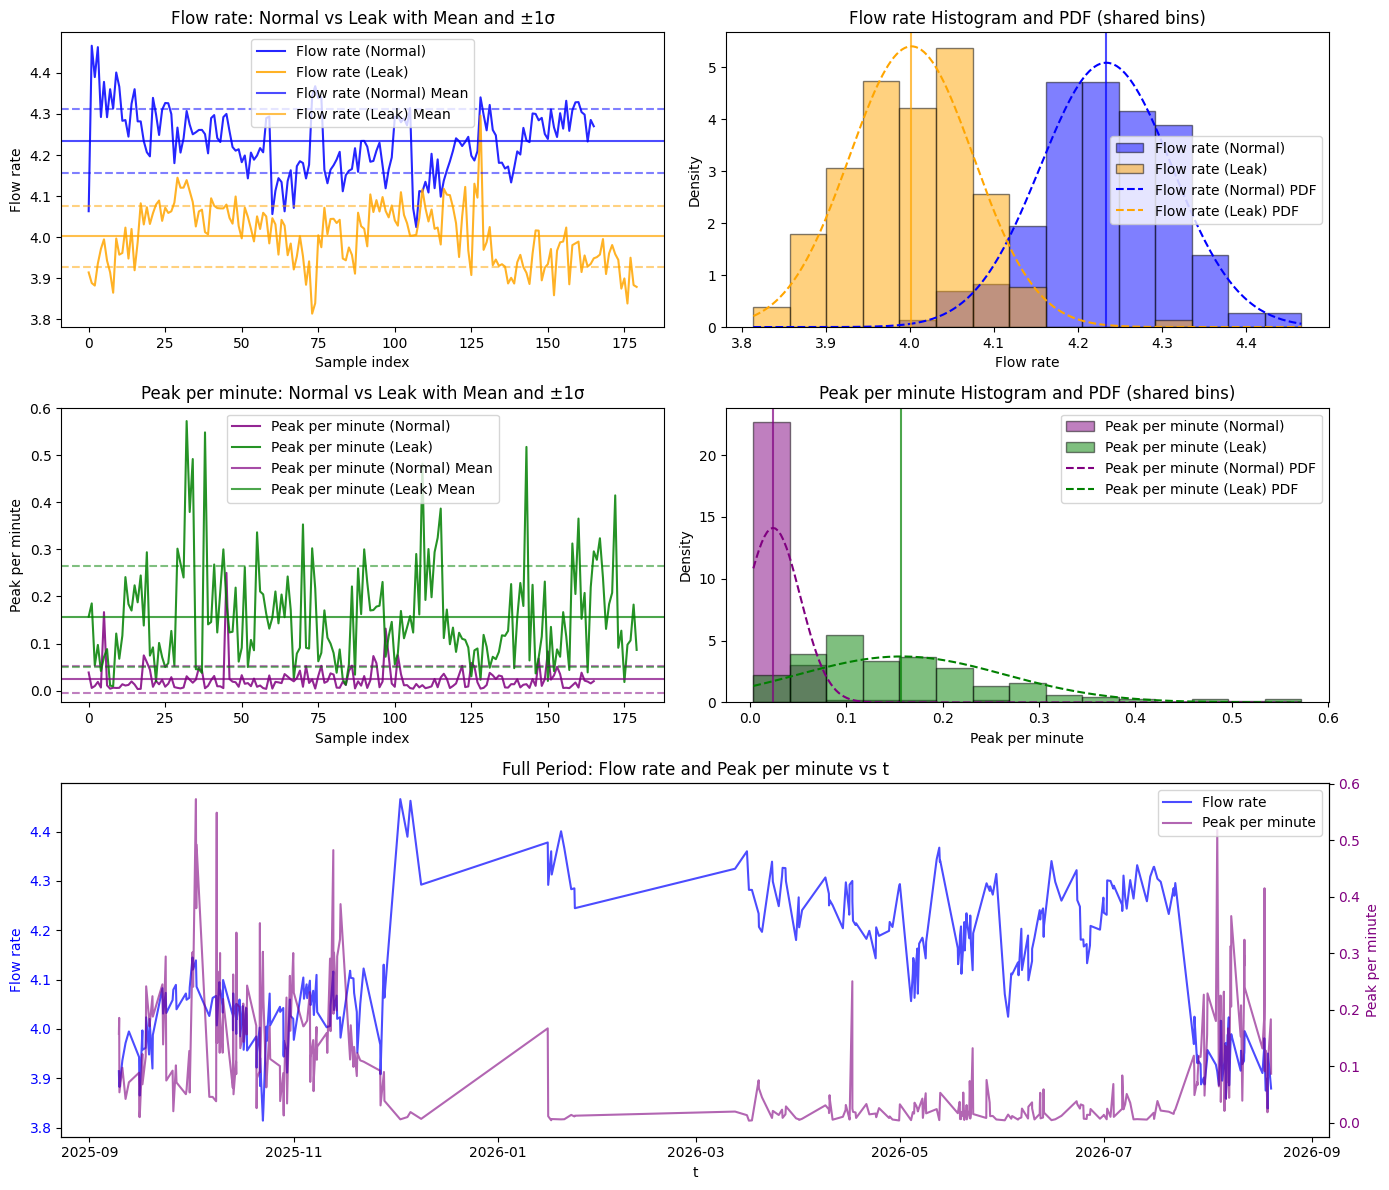

In [5]:
# Example usage (uncomment to test in the notebook context):
plot_feature_distributions_compare(Q1, Q2, Y1, Y2, t=t, Q=Q, Y=Y)

In [6]:

n_normal = 150
n_leak = 150

# Normal regime
#Q1 = np.random.normal(4, 0.2, n_normal)
#Y1 = np.random.normal(1, 10, n_normal)

# Leak regime
#Q2 = np.random.normal(4.5, 0.2, n_leak)
#Y2 = np.random.normal(0, 0.2, n_leak)

#Q = np.concatenate([Q1, Q2])
#Y = np.concatenate([Y1, Y2])

true_cp = n_normal

Q_norm = (Q - np.mean(Q)) / np.std(Q)
Y_norm = (Y - np.mean(Y)) / np.std(Y)
dQ = np.gradient(Q_norm)

dY = np.gradient(Y_norm)

X = np.column_stack([Q_norm, dQ, Y_norm, dY])

In [7]:
cp_probs, R = bocpd_multivariate(X, hazard=1 / 100)

# R[0, t] is always ~hazard after normalization, so thresholding cp_probs cannot work.
# Use MAP run-length collapse at the changepoint instead.
map_rl = np.argmax(R[:, 1:], axis=0)
rl_drop = -np.diff(map_rl, prepend=map_rl[0])
cp_probs = rl_drop.astype(float)

threshold = 50
alarm = rl_drop >= threshold

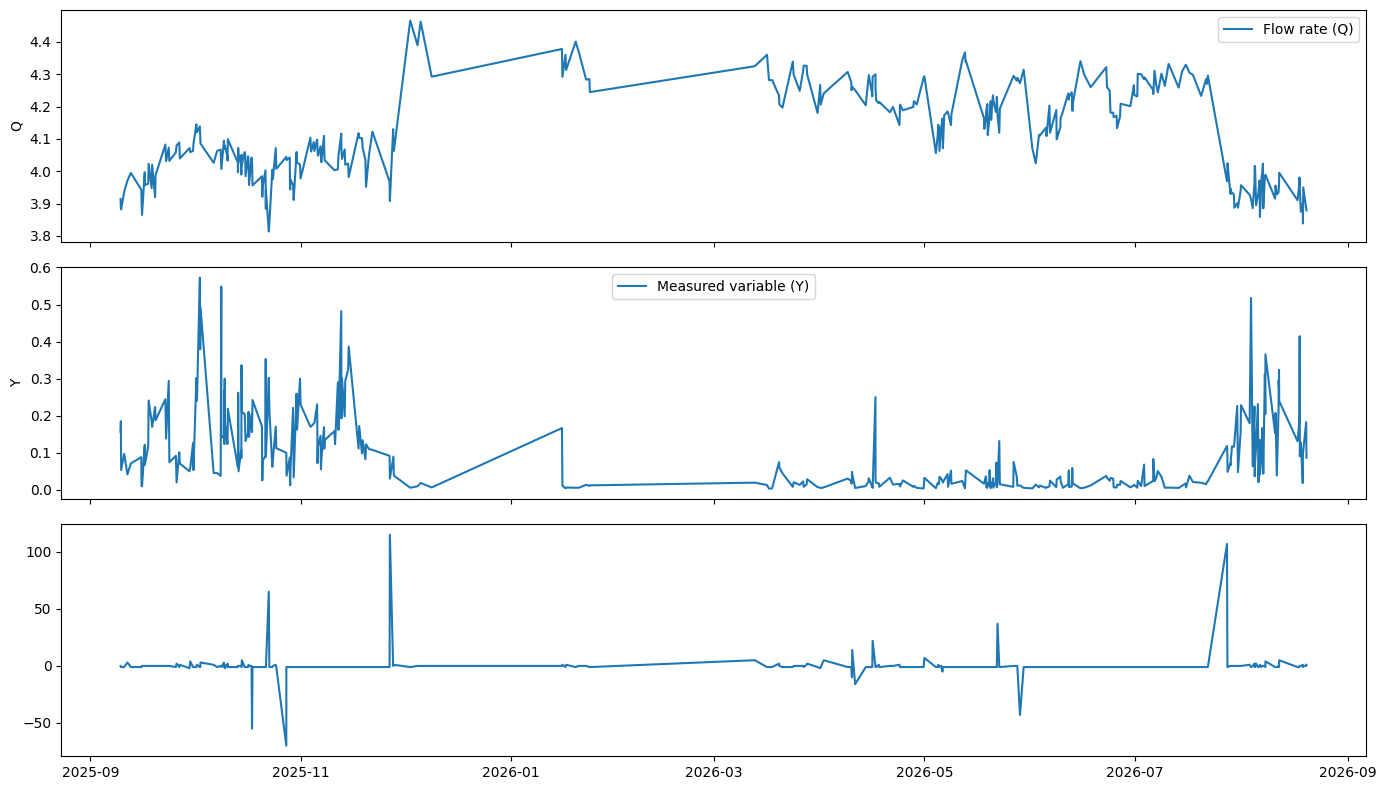

Alarm first triggered at t=73


In [8]:
fig, ax = plt.subplots(3, 1, figsize=(14, 8), sharex=True)
ax[0].plot(t,Q, label="Flow rate (Q)")
ax[0].set_ylabel("Q")
ax[0].legend()


ax[1].plot(t,Y, label="Measured variable (Y)")
ax[1].set_ylabel("Y")
ax[1].legend()


ax[2].plot(t,cp_probs, label="Run-length drop score")
#plt.axvline(true_cp, color="red", linestyle="--", label="True leak start")
alarm_idx = np.where(alarm)[0]

plt.tight_layout()
plt.show()
if len(alarm_idx) > 0:
    print(f"Alarm first triggered at t={alarm_idx[0]}")
else:
    print("No alarm triggered")